# SHAP Analysis — Directional Feature Effects
Explains *how* each feature drives the predicted NDVI anomaly.
Uses TreeExplainer on the RF base model averaged across all 8 output weeks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.model_selection import train_test_split
import os

os.makedirs('../img', exist_ok=True)

/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Reconstruct clean feature set (must match forest_ensemble.ipynb Option A) ---
df = pd.read_pickle('../data/df.pkl')
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

leakage_cols = []
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and any(col.endswith(f'_{m}') for m in range(36, 45))]
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]
leakage_cols += [col for col in df.columns if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_')) and int(col.rsplit('_', 1)[-1]) >= 36]
leakage_cols += [c for c in ['ndvi_mean','ndvi_cov','ndvi_std','ndvi_mean_norm','ndvi_std_norm','ndvi_cov_norm','health'] if c in df.columns]
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]
leakage_cols += [col for col in df.columns if col.endswith('length')]

drop_cols = set(leakage_cols + ['plot_id', 'year'] + target_cols)
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_cols]

X_train, X_tune, y_train, y_tune = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42)
print(f'Test set: {X_test.shape}')

Test set: (4318, 283)


In [3]:

# --- Load model and extract RF estimators ---
# Saved preprocessor is sklearn 1.7.2; current env is 1.8.0 — refit fresh instead.
# RF trees are threshold-based and unaffected by refit on the same data.
model = joblib.load('models/tree_ensemble.pkl')
multi = model.named_steps['regressor'].regressor_

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.select_dtypes(include=['float64','int64']).columns.tolist()

fresh_pre = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler())
])
X_train_t = fresh_pre.fit_transform(X_train[numeric_features])
X_test_t  = fresh_pre.transform(X_test[numeric_features])
print(f'Transformed test shape: {X_test_t.shape}')


Transformed test shape: (4318, 282)


In [4]:

# --- Compute SHAP values for each output, average ---
# Sample 800 points for speed
np.random.seed(42)
idx = np.random.choice(len(X_test_t), size=min(800, len(X_test_t)), replace=False)
X_shap = X_test_t[idx]

shap_vals_list = []
for i, stacked in enumerate(multi.estimators_):
    rf = stacked.estimators_[0]  # RF is first base model
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(X_shap)
    shap_vals_list.append(sv)
    print(f'  Output {i} done')

# Average absolute SHAP across outputs
shap_vals_mean = np.mean(np.abs(shap_vals_list), axis=0)  # (samples, features)
print(f'SHAP values shape: {shap_vals_mean.shape}')


  Output 0 done
  Output 1 done
  Output 2 done
  Output 3 done
  Output 4 done
  Output 5 done
  Output 6 done
  Output 7 done
SHAP values shape: (800, 282)


In [5]:
# --- Mean absolute SHAP by feature group ---
mean_abs_shap = shap_vals_mean.mean(axis=0)
shap_series = pd.Series(mean_abs_shap, index=numeric_features).sort_values(ascending=False)

def bucket(n):
    n = n.lower()
    if any(k in n for k in ['elev','slope','aspect','curve','tpi','tri','hill','rough','flow','area']): return 'terrain'
    if any(k in n for k in ['awc','ph1','ksat','cec','clay','sand','silt','drain','restric','frag','wthird','wfifteen','wsatiated','profile','dbovendry']): return 'soil'
    if any(k in n for k in ['tmax','tmin','tmean','precip','vpd','srad','wind','pet','erc','rmin','rmax','sph','vs','bi','fm100','fm1000','diurnal']): return 'climate'
    if 'ndvi' in n: return 'ndvi_early'
    return 'other'

groups = shap_series.groupby(shap_series.index.map(bucket)).sum()
total = groups.sum()
print('=== Mean |SHAP| by group ===')
for g, v in groups.sort_values(ascending=False).items():
    print(f'  {g}: {v/total*100:.1f}%')

=== Mean |SHAP| by group ===
  terrain: 75.5%
  ndvi_early: 15.1%
  climate: 5.4%
  other: 2.9%
  soil: 1.1%


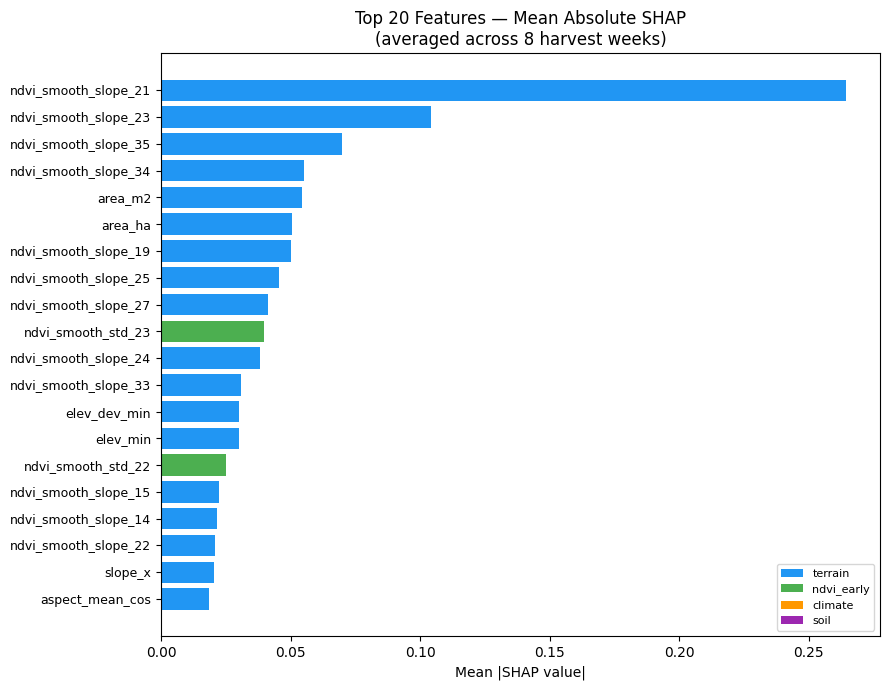

In [6]:
# --- Plot: Top 20 features by mean |SHAP| ---
top20 = shap_series.head(20)
colors = [plt.colormaps['tab10'](i % 10) for i in range(len(top20))]

group_colors = {'terrain': '#2196F3', 'ndvi_early': '#4CAF50', 'climate': '#FF9800', 'soil': '#9C27B0', 'other': '#9E9E9E'}
bar_colors = [group_colors.get(bucket(f), '#9E9E9E') for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(range(len(top20)), top20.values[::-1], color=bar_colors[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 Features — Mean Absolute SHAP\n(averaged across 8 harvest weeks)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in group_colors.items() if g != 'other']
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../img/shap_top20.png', dpi=150, bbox_inches='tight')
plt.show()

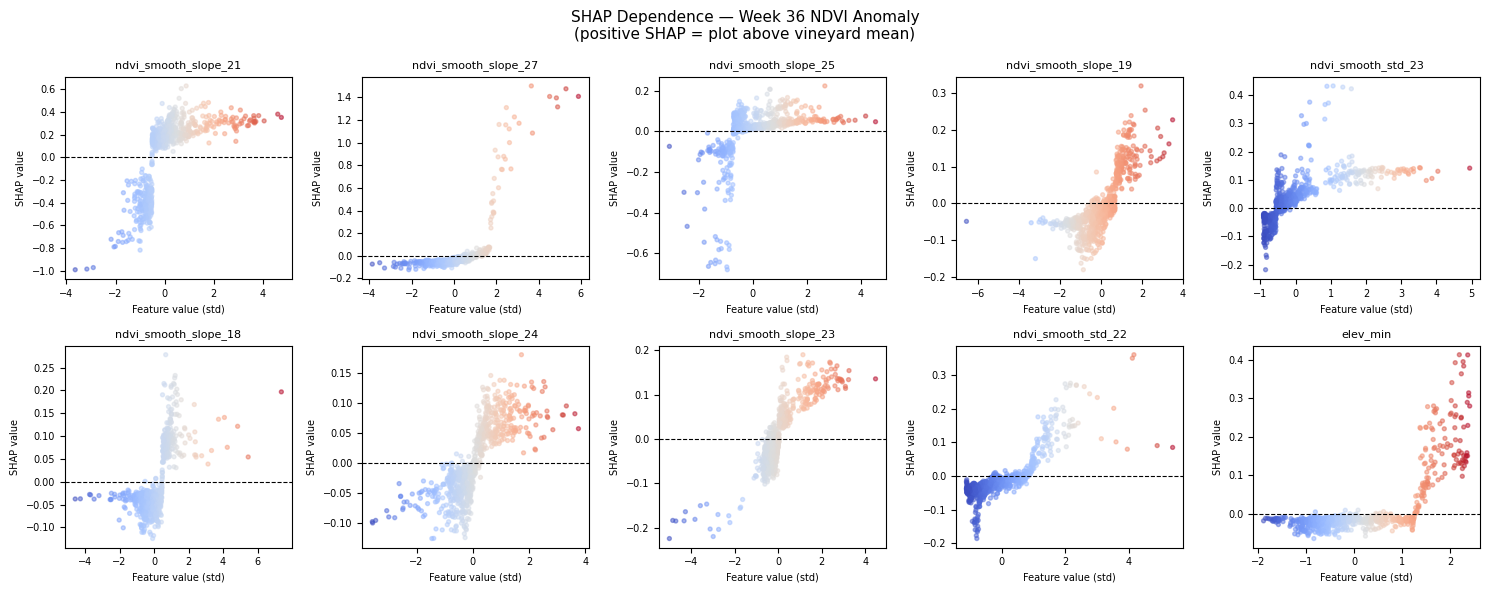

In [7]:

# --- Directional SHAP: signed values for week 36 (earliest harvest) ---
explainer_w36 = shap.TreeExplainer(multi.estimators_[0].estimators_[0])
shap_w36 = explainer_w36.shap_values(X_shap)  # (samples, features)

# Top 10 features by mean |SHAP| for week 36
top10_idx = np.argsort(np.abs(shap_w36).mean(axis=0))[::-1][:10]
top10_names = [numeric_features[i] for i in top10_idx]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, fi, fname in zip(axes.flat, top10_idx, top10_names):
    feat_vals = X_shap[:, fi]
    sv = shap_w36[:, fi]
    sc = ax.scatter(feat_vals, sv, c=feat_vals, cmap='coolwarm', alpha=0.5, s=8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_title(fname, fontsize=8)
    ax.set_xlabel('Feature value (std)', fontsize=7)
    ax.set_ylabel('SHAP value', fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('SHAP Dependence — Week 36 NDVI Anomaly\n(positive SHAP = plot above vineyard mean)', fontsize=11)
plt.tight_layout()
plt.savefig('../img/shap_dependence_w36.png', dpi=150, bbox_inches='tight')
plt.show()


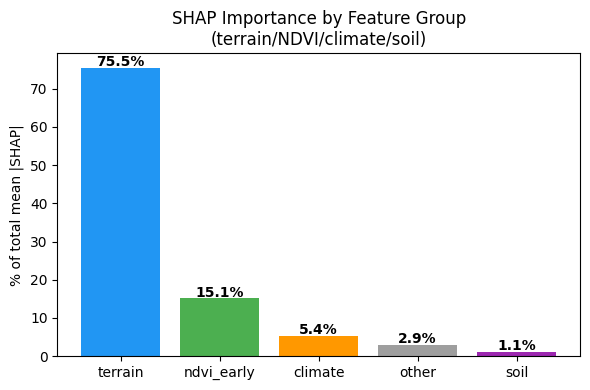

In [8]:
# --- Group-level SHAP bar chart ---
fig, ax = plt.subplots(figsize=(6, 4))
grp = groups.sort_values(ascending=False)
cols = [group_colors.get(g, '#9E9E9E') for g in grp.index]
ax.bar(grp.index, grp.values / total * 100, color=cols)
ax.set_ylabel('% of total mean |SHAP|')
ax.set_title('SHAP Importance by Feature Group\n(terrain/NDVI/climate/soil)')
for i, (g, v) in enumerate(grp.items()):
    ax.text(i, v/total*100 + 0.5, f'{v/total*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/shap_groups.png', dpi=150, bbox_inches='tight')
plt.show()